# Visualizing O(3) field configurations and SDEdit

This notebook visualizes configurations of the two-dimensional O(3) model at $\beta=1.5$ and applies the trained $64\times64$ score model to Georges Seurat's *A Sunday Afternoon on the Island of La Grande Jatte*.

The diffusion model is convolutional, so although it was trained on $64\times64$ lattices it can be applied directly to a much larger field. The saved `seurat_spins.pt` configuration is used for the quantitative checks and final figures so that these are reproducible despite the stochastic SDEdit procedure.


## Initialization


In [2]:
import colorsys
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
from tqdm.notebook import tqdm

import model
import mcmc_2d as mcmc
import rotation as rot
import sde
import sphere

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}\t" + (f"{torch.cuda.get_device_name(0)}" if torch.cuda.is_available() else "CPU"))

sphere.setDevice(device)

beta = 1.5

uNet64 = model.UNet(dim = 2, num_blocks=(2,2,2)).to(device)
uNet64.load_state_dict(torch.load("data/Models/uNet2D_BEST_epoch1300.pt", map_location=device))
uNet64.eval()

# Correlation function measured from the 64 x 64 MCMC training ensemble.
corrTraining = [1.,0.6017,0.4339,0.3402,0.2781,0.2328,0.1978,0.1698,0.1469,0.1279,0.1120,0.0985,0.0869,0.0770,0.0684,
    0.0609,0.0545,0.0488,0.0439,0.0396,0.0359,0.0326,0.0298,0.0274,0.0254,0.0236,0.0221,0.0210,0.0200,0.0193,0.0187,0.0184,0.0183]

def score(x, t, scoreNet):
    u = sde.uFromTau(t)
    with torch.no_grad():
        omega = scoreNet(x, u)
        return torch.cross(omega, x, dim=-1)


Using device: cuda	NVIDIA L4


## Spin-field visualization

A spin $\mathbf n=(n_x,n_y,n_z)\in S^2$ is mapped to color by using its azimuth as hue and $n_z$ as lightness. The same map is used for genuine field configurations and for the image-derived spin field below.


In [5]:
def vectors_to_rgb(v):
    """
    v: numpy array of shape (H, W, 3), with ||v|| <= 1

    Returns:
        rgb: numpy array of shape (H, W, 3), values in [0,1]
    """
    x = v[..., 0]
    y = v[..., 1]
    z = np.clip(v[..., 2], -1.0, 1.0)

    # Hue: azimuth around z axis
    H = np.mod(np.arctan2(y, x) / (2*np.pi), 1.0)

    # Lightness: south pole -> black, north pole -> white
    L = (1.0 + z) / 2.0

    # Saturation: radial position within the disk at fixed z
    rho = np.sqrt(x*x + y*y)
    rho_max = np.sqrt(np.maximum(1.0 - z*z, 0.0))

    S = np.divide(
        rho,
        rho_max,
        out=np.zeros_like(rho),
        where=rho_max > 1e-12
    )
    S = np.clip(S, 0.0, 1.0)

    hls = np.stack([H, L, S], axis=-1)
    flat = hls.reshape(-1, 3)

    rgb = np.array([
        colorsys.hls_to_rgb(h, l, s)
        for h, l, s in flat
    ])

    return rgb.reshape(v.shape)


  0%|          | 0/800 [00:00<?, ?it/s]

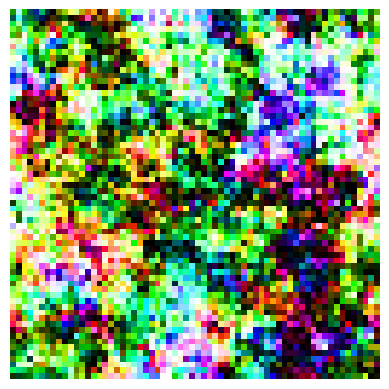

In [ ]:
L = 64
cfgEq = mcmc.randomSpins(1, L, device=device)
cfgEq = mcmc.heatBath(cfgEq, beta, 800)

rgbEq = vectors_to_rgb(cfgEq.squeeze().cpu().numpy())

plt.figure()
plt.imshow(rgbEq)
plt.axis("off")
plt.show()


## Mapping an RGB image to spins

An RGB pixel has three degrees of freedom, while a unit spin has two. I first project each pixel onto a face of the RGB cube, then use its HLS hue and lightness as the two coordinates on $S^2$.

I tried both deterministic projection to the nearest face (`pure_saturate`) and a stochastic projection that preserves each selected RGB component in expectation (`stochastic_saturate`). The stochastic version preserved the appearance of the painting better, so it is used for SDEdit below.


In [4]:
def stochastic_saturate(rgb):
    """
    rgb: (..., 3) array with values in [0,1].

    For each pixel, choose the RGB channel nearest {0,1},
    then stochastically snap that channel to 0 or 1 while
    preserving the original RGB value in expectation.
    """
    rgb = np.asarray(rgb, dtype=np.float32)

    dist = np.minimum(rgb, 1 - rgb)
    k = np.argmin(dist, axis=-1)

    out = rgb.copy()

    x = np.take_along_axis(rgb, k[..., None], axis=-1)[..., 0]
    snapped = (np.random.random(x.shape) < x).astype(np.float32)

    np.put_along_axis(out, k[..., None], snapped[..., None], axis=-1)

    return out

def pure_saturate(rgb):
    """
    Project each RGB pixel onto the nearest face of the RGB cube.

    rgb: (..., 3), values in [0, 1]
    """
    rgb = np.asarray(rgb, dtype=np.float32)

    dist = np.minimum(rgb, 1 - rgb)
    k = np.argmin(dist, axis=-1)

    out = rgb.copy()

    x = np.take_along_axis(rgb, k[..., None], axis=-1)[..., 0]
    snapped = (x >= 0.5).astype(np.float32)

    np.put_along_axis(out, k[..., None], snapped[..., None], axis=-1)

    return out

def hls_to_spin(hls):
    H = hls[..., 0]
    L = hls[..., 1]

    phi = 2 * np.pi * H
    z = 2 * L - 1
    rho = np.sqrt(np.maximum(1 - z*z, 0.0))

    x = rho * np.cos(phi)
    y = rho * np.sin(phi)

    return np.stack([x, y, z], axis=-1)


## A Sunday Afternoon


In [ ]:
img = Image.open("data/Images/A_Sunday_on_La_Grande_Jatte.jpg").convert("RGB")
rgb = np.array(img, dtype=np.float32) / 255.0

# Square crop used for the large-lattice SDEdit example.
rgbCrop = rgb[700:700+1856, :1856, :]
print(rgbCrop.shape)

(1856, 1856, 3)


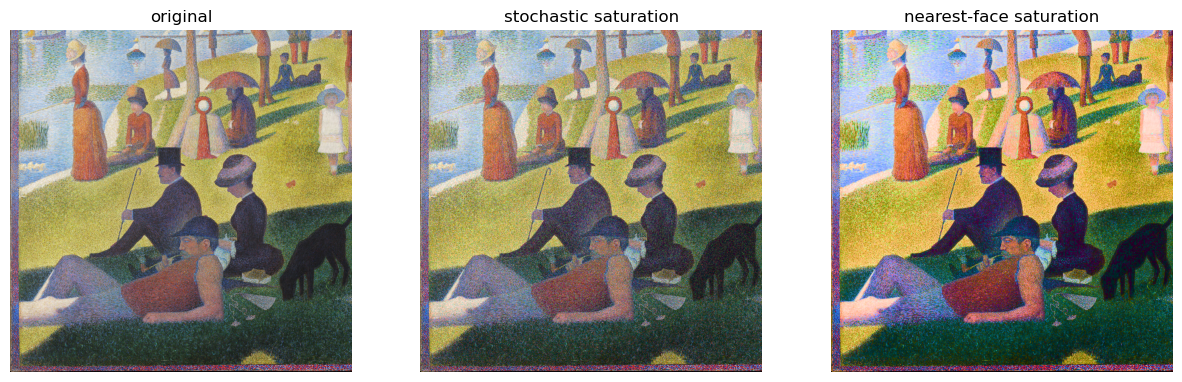

In [ ]:
rgbStochastic = stochastic_saturate(rgbCrop)
rgbPure = pure_saturate(rgbCrop)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(rgbCrop)
ax[0].set_title("original")
ax[1].imshow(rgbStochastic)
ax[1].set_title("stochastic saturation")
ax[2].imshow(rgbPure)
ax[2].set_title("nearest-face saturation")
for a in ax:
    a.axis("off")
plt.show()


In [ ]:
flat = rgbStochastic.reshape(-1, 3)
hls = np.array([
    colorsys.rgb_to_hls(r, g, b)
    for r, g, b in flat
])
hls = hls.reshape(rgbStochastic.shape)

spin = hls_to_spin(hls)
spinBatch = spin.reshape((1,)+spin.shape)
spin_torch = torch.from_numpy(spinBatch).to(torch.float32).to(device)


### SDEdit

The image-derived spin field is diffused to $u=0.7$ and then evolved back to $u=0$ with the learned score. This applies the same convolutional network trained on $64\times64$ configurations to an $1856\times1856$ field.

The procedure is stochastic. The repository therefore includes the particular output used for the figures and diagnostics as `seurat_spins.pt`; the generation cells below should produce a statistically similar but not identical result when rerun.


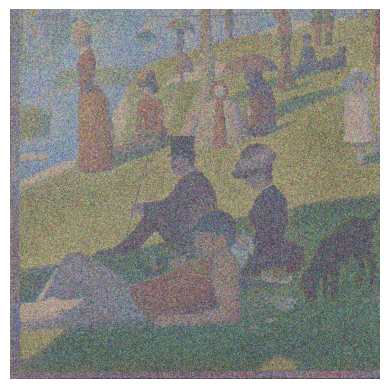

In [ ]:
uEdit = .7
spin_noised = sphere.hk(spin_torch, sde.tauFromU(uEdit))

rgbNoised = vectors_to_rgb(spin_noised.squeeze().cpu().numpy())

plt.figure()
plt.imshow(rgbNoised)
plt.axis("off")
plt.show()


In [ ]:
tau = sde.tauFromU(torch.linspace(uEdit, 0.0, 201))

cfgsGenerated = spin_noised.clone()
for i in tqdm(range(len(tau)-1)):
    dt = tau[i]-tau[i+1]
    cfgsGenerated = sde.eulerMaruyamaStep(cfgsGenerated, tau[i], dt, lambda x, t : score(x, t, uNet64))

rgbGenerated = vectors_to_rgb(cfgsGenerated.squeeze().cpu().numpy())

plt.figure()
plt.imshow(rgbGenerated)
plt.axis("off")
plt.show()

# The committed reference sample was saved from a successful run:
# torch.save(cfgsGenerated, "data/seurat_spins.pt")


## The saved Seurat field

From here on I load the committed SDEdit sample so that the figures and quantitative checks use exactly the same field on every run.


torch.Size([1, 1856, 1856, 3])


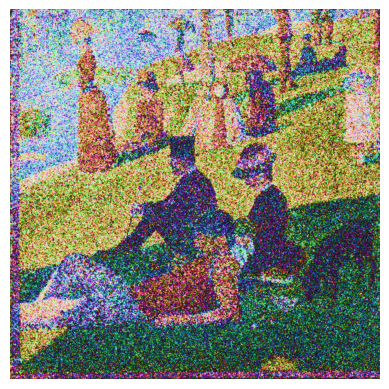

In [6]:
seuratSpins = torch.load("data/seurat_spins.pt", map_location=device)
print(seuratSpins.shape)

seuratImage = vectors_to_rgb(seuratSpins.squeeze().cpu().numpy())

plt.figure()
plt.imshow(seuratImage)
plt.axis("off")
plt.show()


### Local field statistics

The SDEdit field should retain the large-scale image while acquiring the short-distance statistics of the O(3) ensemble. Since the Seurat field is much larger than the training lattice, only the separations of interest are evaluated here rather than constructing the full $1856$-point correlation function.


In [ ]:
def correlationAt(cfgs, r):
    corrX = torch.sum(torch.roll(cfgs, -r, dims=-2) * cfgs, dim=-1).mean()
    corrY = torch.sum(torch.roll(cfgs, -r, dims=-3) * cfgs, dim=-1).mean()
    return .5*(corrX+corrY)

for r in [1,2,4,8]:
    print(r, correlationAt(seuratSpins, r).item(), corrTraining[r])


1 0.6004883050918579 0.6017
2 0.44211894273757935 0.4339
4 0.3183959424495697 0.2781
8 0.2530766725540161 0.1469


In [ ]:
top = torch.load("data/topology_reference.pt")

nD = sum(top["defect_counts"].values())
meanDefects = sum(d*count for d, count in top["defect_counts"].items()) / nD
referenceDefectDensity = meanDefects / 64**2

Q1Seurat, Q2Seurat, defectsSeurat = mcmc.topCharge(seuratSpins)
volumeSeurat = seuratSpins.shape[-3] * seuratSpins.shape[-2]
seuratDefectDensity = defectsSeurat.item() / volumeSeurat

print("Q1, Q2:", Q1Seurat.item(), Q2Seurat.item())
print("Seurat dislocations:", defectsSeurat.item())
print("dislocations/site")
print("Seurat:", seuratDefectDensity)
print("MCMC:  ", referenceDefectDensity)


Q1, Q2: 45.99968338012695 1.0000853538513184
Seurat dislocations: 8277.0537109375
dislocations/site
Seurat: 0.002402812207071166
MCMC:   0.00226067138671875


### A 64 x 64 patch

The score network was trained on $64\times64$ lattices. A crop of exactly that size from the SDEdit field can therefore be compared directly with a genuine equilibrium configuration using the same color map.


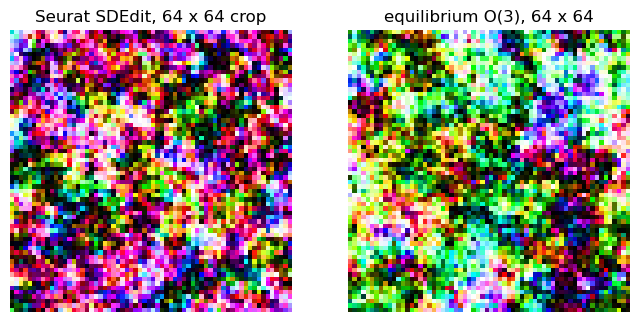

In [ ]:
y0, x0 = 764, 824
seuratCrop = seuratImage[y0:y0+64, x0:x0+64, :]

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(seuratCrop)
ax[0].set_title("Seurat SDEdit, 64 x 64 crop")
ax[1].imshow(rgbEq)
ax[1].set_title("equilibrium O(3), 64 x 64")
for a in ax:
    a.axis("off")
plt.show()


## Quenching the Seurat field

I also explored quenching as a way to remove ultraviolet dislocations and make the smoother Skyrmion-like structures easier to see. One motivation was the Berg--Lüscher observation that after sufficient smoothing the two plaquette triangulations can agree, $Q_1=Q_2$. I do not use the quenched field as the main topology estimator here; this is retained as a visual and qualitative diagnostic.

A global O(3) rotation is applied first only to change the color orientation of the visualization. It leaves the action and topological observables unchanged.


In [16]:
torch.manual_seed(1)
mat = rot.rotFromQ(rot.randomQ(device=device))
seuratRot = torch.einsum('ij,...j->...i', mat, seuratSpins)

Q1Before, Q2Before, defectsBefore = mcmc.topCharge(seuratRot)
print("before quench:", Q1Before.item(), Q2Before.item(), defectsBefore.item())

rgbBefore = vectors_to_rgb(seuratRot.squeeze().cpu().numpy())


before quench: 45.99965286254883 1.000058650970459 8277.0546875


A global O(3) rotation changes the overall color scheme.

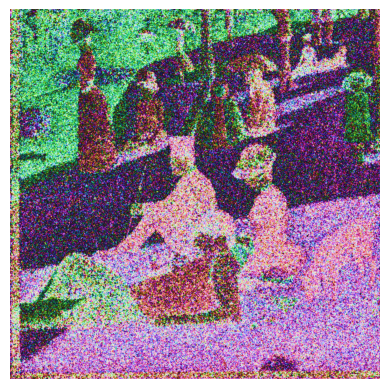

In [ ]:
plt.figure()
plt.imshow(rgbBefore)
plt.axis("off")
plt.show()

In [8]:
spinsQuench = seuratRot.clone()

ds = .1
tSteps = 10000
scoreExact = lambda x, t : mcmc.exactScore(x, 1.0)

for _ in tqdm(range(tSteps)):
    spinsQuench = sde.quenchStep(spinsQuench, 1.0, ds, scoreExact)

Q1After, Q2After, defectsAfter = mcmc.topCharge(spinsQuench)
print("after quench: ", Q1After.item(), Q2After.item(), defectsAfter.item())


  0%|          | 0/10000 [00:00<?, ?it/s]

after quench:  -4.999999523162842 -5.000000476837158 0.0008697657031007111


Topological defects (Skyrmions) are clearly visible after quenching

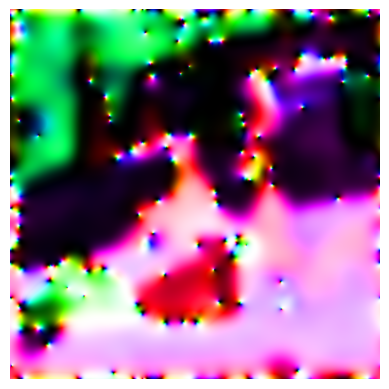

In [ ]:
rgbAfter = vectors_to_rgb(spinsQuench.squeeze().cpu().numpy())
plt.figure()
plt.imshow(rgbAfter)
plt.axis("off")
plt.show()